In [22]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from fuzzywuzzy import fuzz

/Users/hendrikweichel/miniconda3/envs/nace_project/lib/python3.10/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [3]:
all_csvs_only_right_chunks = glob.glob("/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/training_data/paragraph_and_sentence_len_5_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx__sample_ratio_1__filter_only_right_chunks/*.csv")
all_dfs_only_right_chunks = dict()
for csv in all_csvs_only_right_chunks: 
    temp_df = pd.read_csv(csv, index_col=0) 
    all_dfs_only_right_chunks[os.path.basename(csv)[:-4]] = temp_df
dfs_only_right_chunks = pd.concat(list(all_dfs_only_right_chunks.values()))
dfs_only_right_chunks

,Evaluation,Notes,Sentences,Score,NACE_Code,Code,Nbr. of Chunks,Avg. Length,Avg. Score,text
0.0,NaN,NaN,the large smolt capacity is the most important...,0.351190,A,NaN,NaN,NaN,NaN,NaN
1.0,NaN,NaN,we are addressing target by sourcing certified...,0.359579,A,NaN,NaN,NaN,NaN,NaN
2.0,NaN,NaN,we are committed to our role as custodians of ...,0.447300,A,NaN,NaN,NaN,NaN,NaN
3.0,NaN,NaN,sustainable fish feed ensuring sustainable and...,0.449386,A,NaN,NaN,NaN,NaN,NaN
4.0,NaN,NaN,optimised the mineral content of the fish feed...,0.393189,A,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
3.0,NaN,NaN,reply operates through a network of companies ...,0.393202,M,NaN,NaN,NaN,NaN,NaN
4.0,NaN,NaN,in terms of training the marcel classes platfo...,0.447932,M,NaN,NaN,NaN,NaN,NaN
5.0,NaN,NaN,wedge.e if it is deemed necessary or appropria...,0.351571,M,NaN,NaN,NaN,NaN,NaN
6.0,NaN,NaN,wedge.e to ensure a strong involvement of mana...,0.376569,M,NaN,NaN,NaN,NaN,NaN


In [4]:
all_csvs = glob.glob("../data/labeled_data/paragraph_and_sentence_len_5_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx_subsample/*.csv")

In [5]:
overview_reports = pd.read_excel("../data/stoxx_600/STOXX600_as_of_2025_03_13.xlsx")
overview_reports
all_reports = glob.glob("../data/stoxx_600/TXTs/*.txt")
all_reports = [os.path.basename(report)[:-4] for report in all_reports]
overview_reports = overview_reports[overview_reports["Report"].apply(lambda x: str(x)[:-4] in all_reports)]
overview_reports

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report
0,SalMar ASA,SALM-NO,SALM-NO,1984.965581,2458.824022,2271.611663,3.21,A,salmar-annual-report-2022.pdf
1,Bakkafrost P/F,BAKKA-NO,BAKKA-NO,929.503079,937.862170,973.053513,3.21,A,Bakkafrost PF2.pdf
2,Antofagasta plc,ANTO-GB,ANTO-GB,5577.681426,5849.975673,6113.946983,7.29,B,Antofagasta plc1.pdf
3,Anglo American plc,AAL-GB,AAL-GB,33423.271144,28355.894415,25288.188492,7.29,B,Anglo American plc1.pdf
4,TotalEnergies SE,TTE-FR,TTE-FR,250538.948328,202517.658053,180837.266896,6.10,B,Totalenergies EP Gabon1.pdf
...,...,...,...,...,...,...,...,...,...
595,Entain PLC,ENT-GB,ENT-GB,5036.123247,5484.020421,6011.923752,93.29,R,Entain PLC1.pdf
596,FDJ United,FDJU-FR,FDJU-FR,2461.100000,2621.400000,3065,93.29,R,kindred-group_2022.pdf
597,Elis SA,ELIS-FR,ELIS-FR,3820.900000,4309.400000,4573.7,96.01,S,Elis - 2022 financial statements.pdf
598,Scout24 SE,G24-DE,G24-DE,447.539000,509.114000,s,96.09,S,Scout24 SE3.pdf


In [6]:
all_dfs = dict()
for csv in all_csvs: 
    temp_df = pd.read_csv(csv, index_col=0) 
    #temp_df["Evaluation"] = temp_df["Evaluation"].apply(lambda x: True if x == "TRUE" else False)
    temp_df = temp_df.astype({"Evaluation":bool})
    all_dfs[os.path.basename(csv)[:-4]] = temp_df

In [7]:
all_classes = list(all_dfs.keys())

In [8]:
all_dfs["A"]

,Evaluation,Notes,Sentences,Score,NACE_Code
0,True,NaN,the manufacture of animal feeds and the provis...,0.636087,A
1,False,Very likely unrelated,environmental aspects e such as climate change...,0.528835,A
2,False,Statement too vague to be a good indicator,ensure constant and continuous attention to th...,0.504775,A
3,False,Statement too vague to be a good indicator,all renewable and nonrenewable environmental r...,0.502061,A
4,True,NaN,the group seeks to secure quality supplies of ...,0.503893,A
5,False,Unrelated,we rely on natural resources to supply water a...,0.505840,A
6,False,Statement too vague to be a good indicator,best environmental practices compliance with e...,0.512339,A
7,False,Sounds more like a financial institution,.b mobilise significant resources from all sou...,0.510274,A
8,False,Sounds more like a financial institution,the conservation and sustainable use of natura...,0.507053,A
9,True,NaN,irrigation systems are also set up on other fa...,0.562982,A


In [9]:
for k, v in all_dfs.items(): 
    print(k)

A
C
T
B
Q
F
G
P
R
E
D
S
I
H
J
K
O
N
L
M


In [10]:
mean_right = {}
for nace_class in all_classes:
    mean_val = all_dfs[nace_class]["Evaluation"].mean()
    print(nace_class, mean_val)
    mean_right[nace_class] = mean_val

A 0.525
C 0.65
T 0.0
B 0.875
Q 0.3
F 0.9
G 0.625
P 0.5625
R 0.6666666666666666
E 1.0
D 0.75
S 0.175
I 0.375
H 0.625
J 1.0
K 0.825
O 0.025
N 0.075
L 0.9
M 0.15


In [11]:
df_count_and_mean_validation = overview_reports.groupby("NACE_letter").count()[["Name"]]
df_count_and_mean_validation 

,Name
NACE_letter,
A,2
B,4
C,111
D,9
E,5
F,7
G,14
H,5
I,5


## Wie sehr ist das abh. von auftauchen der Klasse in dem Datensatz?

/var/folders/fp/yhl61lbj3m73x3_17tsp1vrr0000gn/T/ipykernel_66727/3400804782.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(counts[i], means[i], nace, fontsize=10, ha='right')


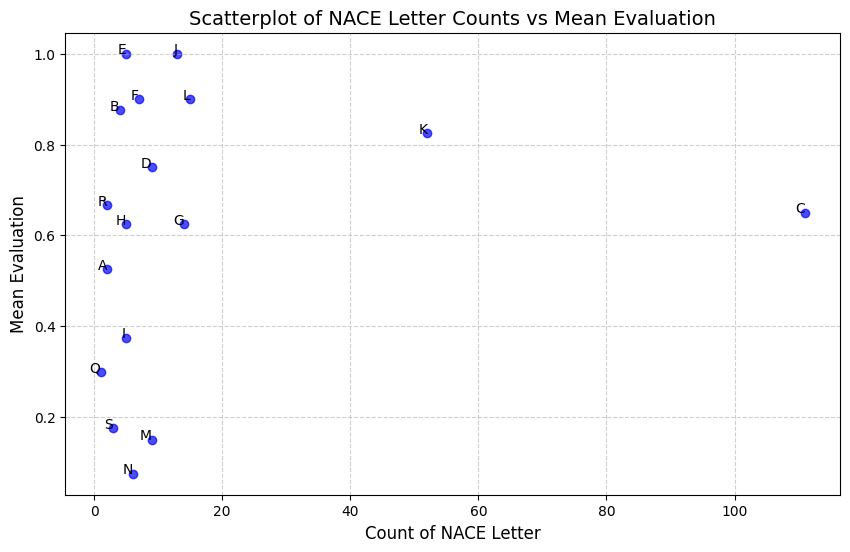

In [12]:
# Extracting data for the scatterplot
nace_letters = df_count_and_mean_validation.index
counts = df_count_and_mean_validation["Name"]
means = [mean_right[nace] for nace in nace_letters]

# Creating the scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(counts, means, color='blue', alpha=0.7)
plt.title("Scatterplot of NACE Letter Counts vs Mean Evaluation", fontsize=14)
plt.xlabel("Count of NACE Letter", fontsize=12)
plt.ylabel("Mean Evaluation", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Annotating points with NACE letters
for i, nace in enumerate(nace_letters):
    plt.text(counts[i], means[i], nace, fontsize=10, ha='right')

plt.show()

## Wie wirkt der Cos sim theshold? 

In [13]:
df_all_results = pd.concat(all_dfs.values())
df_all_results.groupby("Evaluation").describe()
df_all_results.groupby("Evaluation").aggregate({'Score': 'mean'})

,Score
Evaluation,
False,0.524532
True,0.537777


In [14]:
# Normalize the distribution by dividing by the total count per score range
normalized_distribution = score_evaluation_distribution.div(score_evaluation_distribution.sum(axis=1), axis=0)

# Plotting the normalized distribution
normalized_distribution.plot(kind='bar', stacked=True, figsize=(10, 6), color=['red', 'green'])
plt.title("Normalized Distribution of Scores by Evaluation", fontsize=14)
plt.xlabel("Score Range", fontsize=12)
plt.ylabel("Proportion", fontsize=12)
plt.legend(title="Evaluation", labels=["False", "True"])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
''

NameError: name 'score_evaluation_distribution' is not defined

## Wie sehr überschneiden sich die richtigen mit “richtigen” Berichten 

In [15]:
dfs_only_right_chunks

,Evaluation,Notes,Sentences,Score,NACE_Code,Code,Nbr. of Chunks,Avg. Length,Avg. Score,text
0.0,NaN,NaN,the large smolt capacity is the most important...,0.351190,A,NaN,NaN,NaN,NaN,NaN
1.0,NaN,NaN,we are addressing target by sourcing certified...,0.359579,A,NaN,NaN,NaN,NaN,NaN
2.0,NaN,NaN,we are committed to our role as custodians of ...,0.447300,A,NaN,NaN,NaN,NaN,NaN
3.0,NaN,NaN,sustainable fish feed ensuring sustainable and...,0.449386,A,NaN,NaN,NaN,NaN,NaN
4.0,NaN,NaN,optimised the mineral content of the fish feed...,0.393189,A,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
3.0,NaN,NaN,reply operates through a network of companies ...,0.393202,M,NaN,NaN,NaN,NaN,NaN
4.0,NaN,NaN,in terms of training the marcel classes platfo...,0.447932,M,NaN,NaN,NaN,NaN,NaN
5.0,NaN,NaN,wedge.e if it is deemed necessary or appropria...,0.351571,M,NaN,NaN,NaN,NaN,NaN
6.0,NaN,NaN,wedge.e to ensure a strong involvement of mana...,0.376569,M,NaN,NaN,NaN,NaN,NaN


In [16]:
df_all_results

,Evaluation,Notes,Sentences,Score,NACE_Code
0,True,NaN,the manufacture of animal feeds and the provis...,0.636087,A
1,False,Very likely unrelated,environmental aspects e such as climate change...,0.528835,A
2,False,Statement too vague to be a good indicator,ensure constant and continuous attention to th...,0.504775,A
3,False,Statement too vague to be a good indicator,all renewable and nonrenewable environmental r...,0.502061,A
4,True,NaN,the group seeks to secure quality supplies of ...,0.503893,A
...,...,...,...,...,...
35,True,NaN,services include installation commissioning te...,0.517566,M
36,False,NaN,regular online it awareness training provided ...,0.548825,M
37,False,NaN,the organisation shall establish documented pr...,0.508497,M
38,False,NaN,to enable us to achieve our strategic objectiv...,0.529304,M


In [17]:
df_all_results["Sentences"].apply(lambda x :x in dfs_only_right_chunks["Sentences"])

0     False
1     False
2     False
3     False
4     False
      ...  
35    False
36    False
37    False
38    False
39    False
Name: Sentences, Length: 718, dtype: bool

In [25]:
df_all_results["Max_Sim"] = df_all_results["Sentences"].apply(lambda x : max([fuzz.ratio(str(sentence), str(x)) for sentence in dfs_only_right_chunks["Sentences"]]))
df_all_results["Max_Sim_sentence"] = df_all_results["Sentences"].apply(
    lambda x: max(dfs_only_right_chunks["Sentences"], key=lambda sentence: fuzz.ratio(str(sentence), str(x)))
)

In [28]:
df_all_results

,Evaluation,Notes,Sentences,Score,NACE_Code,Max_Sim,Max_Sim_sentence
0,True,NaN,the manufacture of animal feeds and the provis...,0.636087,A,100,the manufacture of animal feeds and the provis...
1,False,Very likely unrelated,environmental aspects e such as climate change...,0.528835,A,100,environmental aspects e such as climate change...
2,False,Statement too vague to be a good indicator,ensure constant and continuous attention to th...,0.504775,A,49,the entity has the intention the availability ...
3,False,Statement too vague to be a good indicator,all renewable and nonrenewable environmental r...,0.502061,A,46,it defines the principles main activities and ...
4,True,NaN,the group seeks to secure quality supplies of ...,0.503893,A,48,the group ensures that its suppliers which gen...
...,...,...,...,...,...,...,...
35,True,NaN,services include installation commissioning te...,0.517566,M,48,the propulsion business generates significant ...
36,False,NaN,regular online it awareness training provided ...,0.548825,M,43,adding value to our customers operations ensur...
37,False,NaN,the organisation shall establish documented pr...,0.508497,M,12,inventory consists of physical items and is ma...
38,False,NaN,to enable us to achieve our strategic objectiv...,0.529304,M,41,completed our materiality impact assessment wi...


In [27]:
df_all_results.to_csv("/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/labeled_data/paragraph_and_sentence_len_5_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx_subsample/full_labeled_dataset.csv")

In [30]:
df_all_results["right_report_class"] = df_all_results["Max_Sim"] == 100
df_all_results

,Evaluation,Notes,Sentences,Score,NACE_Code,Max_Sim,Max_Sim_sentence,right_report_class
0,True,NaN,the manufacture of animal feeds and the provis...,0.636087,A,100,the manufacture of animal feeds and the provis...,True
1,False,Very likely unrelated,environmental aspects e such as climate change...,0.528835,A,100,environmental aspects e such as climate change...,True
2,False,Statement too vague to be a good indicator,ensure constant and continuous attention to th...,0.504775,A,49,the entity has the intention the availability ...,False
3,False,Statement too vague to be a good indicator,all renewable and nonrenewable environmental r...,0.502061,A,46,it defines the principles main activities and ...,False
4,True,NaN,the group seeks to secure quality supplies of ...,0.503893,A,48,the group ensures that its suppliers which gen...,False
...,...,...,...,...,...,...,...,...
35,True,NaN,services include installation commissioning te...,0.517566,M,48,the propulsion business generates significant ...,False
36,False,NaN,regular online it awareness training provided ...,0.548825,M,43,adding value to our customers operations ensur...,False
37,False,NaN,the organisation shall establish documented pr...,0.508497,M,12,inventory consists of physical items and is ma...,False
38,False,NaN,to enable us to achieve our strategic objectiv...,0.529304,M,41,completed our materiality impact assessment wi...,False


In [33]:
df_all_results.groupby("right_report_class").agg({"Evaluation":"mean"})

,Evaluation
right_report_class,
False,0.453782
True,0.669421
